In [2]:
!pip install -q timm seaborn

In [ ]:
import os, shutil, random, copy, json, time, warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

warnings.filterwarnings('ignore')

DEFECTIVE_DIR  = '/kaggle/input/datasets/vidishagar/not-ok-merged/not_ok_merged'   # 102 zoomed defect images
GOOD_FULL_DIR  = '/kaggle/input/datasets/vidishagar/ok-merged/OK PHOTOS_MERGED'   # good PCB images
# ──────────────────────────────────────────────────

WORK_DIR       = '/kaggle/working'
PATCHES_DIR    = f'{WORK_DIR}/good_patches'
DATASET_DIR    = f'{WORK_DIR}/dataset'
MODEL_PATH     = f'{WORK_DIR}/pcb_best_model.pth'

# Training hyperparameters
IMG_SIZE       = 224
BATCH_SIZE     = 16
NUM_EPOCHS     = 30
LR             = 1e-4
PATIENCE       = 7        # early stopping
VAL_SPLIT      = 0.2
PATCH_OVERLAP  = 0.25     # 25% overlap when tiling good images
RANDOM_SEED    = 42

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.9.0+cu126


Defective images : 207
Good full images : 1061

Patch size to use: 1280 x 720 px


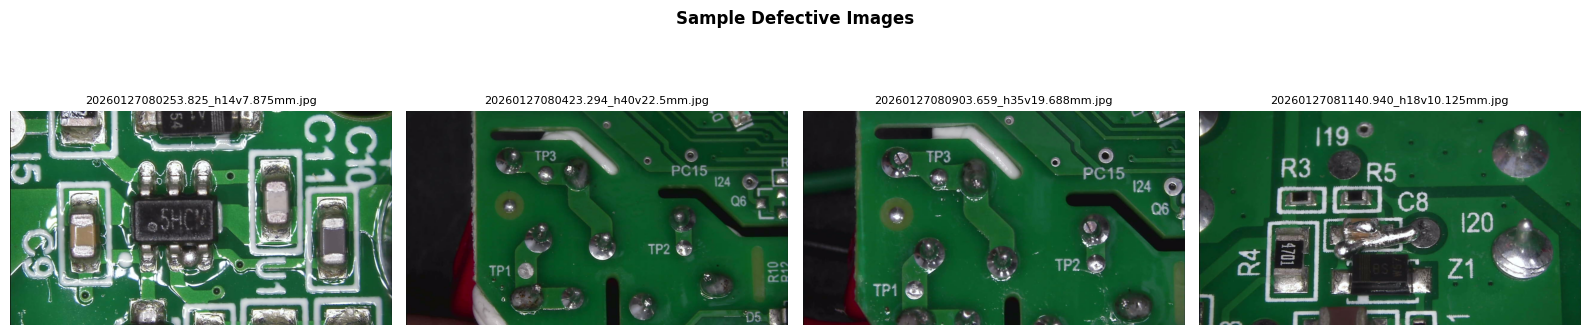

In [ ]:
def get_image_paths(folder):
    exts = ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG')
    paths = []
    for ext in exts:
        paths.extend(Path(folder).glob(ext))
    return sorted(paths)

defect_imgs  = get_image_paths(DEFECTIVE_DIR)
good_imgs    = get_image_paths(GOOD_FULL_DIR)

print(f'Defective images : {len(defect_imgs)}')
print(f'Good full images : {len(good_imgs)}')

# Auto-detect patch size from defect images
sizes = set()
for p in defect_imgs:
    img = cv2.imread(str(p))
    if img is not None:
        sizes.add(img.shape[:2])  # (H, W)

if len(sizes) > 1:
    print(f'WARNING: Mixed sizes found: {sizes}')
    from collections import Counter
    PATCH_H, PATCH_W = Counter(
        cv2.imread(str(p)).shape[:2] for p in defect_imgs if cv2.imread(str(p)) is not None
    ).most_common(1)[0][0]
else:
    PATCH_H, PATCH_W = sizes.pop()

print(f'\nPatch size to use: {PATCH_W} x {PATCH_H} px')

# Preview a few defect images
fig, axes = plt.subplots(1, min(4, len(defect_imgs)), figsize=(16, 4))
for ax, p in zip(axes, defect_imgs[:4]):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(p.name, fontsize=8); ax.axis('off')
plt.suptitle('Sample Defective Images', fontweight='bold')
plt.tight_layout(); plt.show()

Train — good: 849  |  defective: 166
Val   — good: 212   |  defective: 41

Class ratio (train): 1 defect per 5 good patches


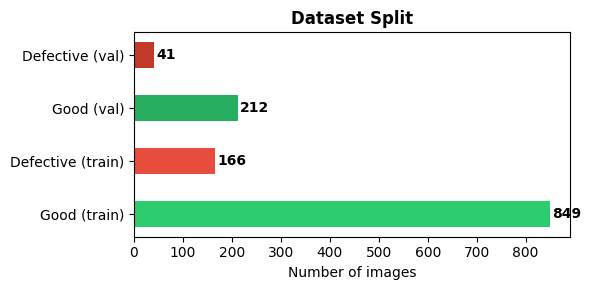

In [6]:
random.seed(RANDOM_SEED)

for split in ['train', 'val']:
    for cls in ['good', 'defective']:
        Path(f'{DATASET_DIR}/{split}/{cls}').mkdir(parents=True, exist_ok=True)

def split_and_copy(src_dir, cls_name):
    imgs = get_image_paths(src_dir)
    random.shuffle(imgs)
    n_val = int(len(imgs) * VAL_SPLIT)
    for img in imgs[n_val:]:
        shutil.copy(img, f'{DATASET_DIR}/train/{cls_name}/{img.name}')
    for img in imgs[:n_val]:
        shutil.copy(img, f'{DATASET_DIR}/val/{cls_name}/{img.name}')
    return len(imgs) - n_val, n_val

g_train, g_val = split_and_copy(GOOD_FULL_DIR, 'good')
d_train, d_val = split_and_copy(DEFECTIVE_DIR, 'defective')

print(f'Train — good: {g_train}  |  defective: {d_train}')
print(f'Val   — good: {g_val}   |  defective: {d_val}')
print(f'\nClass ratio (train): 1 defect per {g_train//d_train} good patches')

# Visualise class balance
fig, ax = plt.subplots(figsize=(6,3))
labels = ['Good (train)', 'Defective (train)', 'Good (val)', 'Defective (val)']
counts = [g_train, d_train, g_val, d_val]
colors = ['#2ecc71','#e74c3c','#27ae60','#c0392b']
bars = ax.barh(labels, counts, color=colors, height=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
            str(count), va='center', fontweight='bold')
ax.set_xlabel('Number of images'); ax.set_title('Dataset Split', fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
def get_transforms(phase):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if phase == 'train':
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

dataset = {
    phase: datasets.ImageFolder(f'{DATASET_DIR}/{phase}', transform=get_transforms(phase))
    for phase in ['train', 'val']
}

# Weighted sampler to handle class imbalance
train_ds     = dataset['train']
class_counts = np.bincount([label for _, label in train_ds.samples])
weights      = 1.0 / class_counts
sw           = torch.tensor([weights[label] for _, label in train_ds.samples])
sampler      = WeightedRandomSampler(sw, len(sw), replacement=True)

loader = {
    'train': DataLoader(dataset['train'], batch_size=BATCH_SIZE, sampler=sampler, num_workers=2),
    'val':   DataLoader(dataset['val'],   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2),
}

CLASS_NAMES  = train_ds.classes   # e.g. ['defective', 'good']
DEFECT_IDX   = CLASS_NAMES.index('defective')

print(f'Classes    : {CLASS_NAMES}')
print(f'Defect idx : {DEFECT_IDX}')
print(f'Train batches: {len(loader["train"])} | Val batches: {len(loader["val"])}')

Classes    : ['defective', 'good']
Defect idx : 0
Train batches: 66 | Val batches: 19


In [16]:
def build_model():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    # Freeze backbone — train only the head first
    for param in model.features.parameters():
        param.requires_grad = False
    in_feats = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_feats, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, len(CLASS_NAMES)),
    )
    return model.to(DEVICE)

model = build_model()
head_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params (head): {head_params:,}')
print(f'Model ready on: {DEVICE}')

Trainable params (head): 328,450
Model ready on: cuda


In [17]:
# Class-weighted loss to further handle imbalance
cw = torch.tensor([1.0 / c for c in class_counts], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

UNFREEZE_EPOCH = 5   # unfreeze backbone after N warmup epochs

best_wts     = copy.deepcopy(model.state_dict())
best_f1      = 0.0
patience_cnt = 0
history      = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

print('Starting training...\n')
t0 = time.time()

for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS}  lr={scheduler.get_last_lr()[0]:.1e}', end='  ')

    # Unfreeze backbone for fine-tuning after warmup
    if epoch == UNFREEZE_EPOCH:
        for param in model.features.parameters():
            param.requires_grad = True
        optimizer.add_param_group({'params': model.features.parameters(), 'lr': LR * 0.1})
        print('[backbone unfrozen]', end='  ')

    val_preds, val_labels = [], []

    for phase in ['train', 'val']:
        model.train() if phase == 'train' else model.eval()
        running_loss = 0.0
        correct = 0

        for inputs, labels in loader[phase]:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                out   = model(inputs)
                loss  = criterion(out, labels)
                preds = out.argmax(dim=1)
                if phase == 'train':
                    loss.backward(); optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            if phase == 'val':
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        ep_loss = running_loss / len(loader[phase].dataset)
        ep_acc  = correct      / len(loader[phase].dataset)
        history[f'{phase}_loss'].append(ep_loss)
        history[f'{phase}_acc'].append(ep_acc)
        print(f'{phase}: loss={ep_loss:.3f} acc={ep_acc:.3f}', end='  ')

    val_f1 = f1_score(val_labels, val_preds, pos_label=DEFECT_IDX, zero_division=0)
    print(f'val_defect_F1={val_f1:.3f}', end='')

    scheduler.step()

    if val_f1 > best_f1:
        best_f1  = val_f1
        best_wts = copy.deepcopy(model.state_dict())
        torch.save(best_wts, MODEL_PATH)
        patience_cnt = 0
        print('  ✓ saved')
    else:
        patience_cnt += 1
        print(f'  (patience {patience_cnt}/{PATIENCE})')
        if patience_cnt >= PATIENCE:
            print('\nEarly stopping.')
            break

model.load_state_dict(best_wts)
print(f'\nTraining done in {(time.time()-t0)/60:.1f} min  |  Best val F1: {best_f1:.4f}')

Starting training...

Epoch 01/30  lr=1.0e-04  train: loss=0.549 acc=0.480  val: loss=1.116 acc=0.266  val_defect_F1=0.421  ✓ saved
Epoch 02/30  lr=1.0e-04  train: loss=0.507 acc=0.487  val: loss=1.093 acc=0.266  val_defect_F1=0.421  (patience 1/7)
Epoch 03/30  lr=9.9e-05  train: loss=0.482 acc=0.494  val: loss=0.996 acc=0.270  val_defect_F1=0.422  ✓ saved
Epoch 04/30  lr=9.8e-05  train: loss=0.480 acc=0.489  val: loss=1.044 acc=0.277  val_defect_F1=0.424  ✓ saved
Epoch 05/30  lr=9.6e-05  train: loss=0.433 acc=0.527  val: loss=1.015 acc=0.308  val_defect_F1=0.435  ✓ saved
Epoch 06/30  lr=9.3e-05  [backbone unfrozen]  train: loss=0.462 acc=0.522  val: loss=0.947 acc=0.353  val_defect_F1=0.452  ✓ saved
Epoch 07/30  lr=9.0e-05  train: loss=0.407 acc=0.586  val: loss=0.784 acc=0.488  val_defect_F1=0.507  ✓ saved
Epoch 08/30  lr=8.7e-05  train: loss=0.390 acc=0.626  val: loss=0.781 acc=0.533  val_defect_F1=0.526  ✓ saved
Epoch 09/30  lr=8.3e-05  train: loss=0.313 acc=0.691  val: loss=0.796 

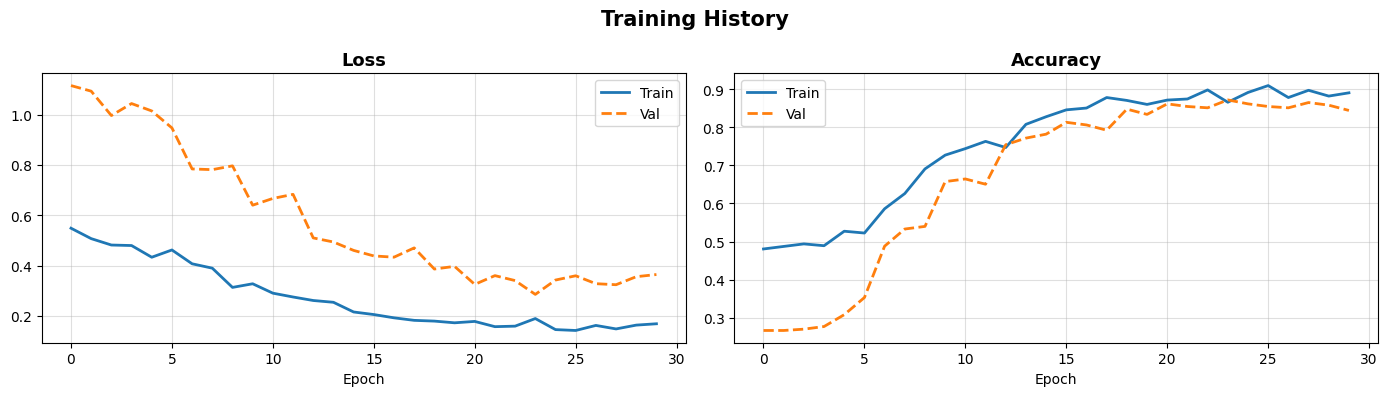

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric, title in zip(axes, ['loss', 'acc'], ['Loss', 'Accuracy']):
    ax.plot(history[f'train_{metric}'], label='Train', linewidth=2)
    ax.plot(history[f'val_{metric}'],   label='Val',   linewidth=2, linestyle='--')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.4)
plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

Classification Report
              precision    recall  f1-score   support

   defective       0.69      0.96      0.80        77
        good       0.98      0.84      0.91       212

    accuracy                           0.87       289
   macro avg       0.83      0.90      0.85       289
weighted avg       0.90      0.87      0.88       289

AUC-ROC: 0.9790


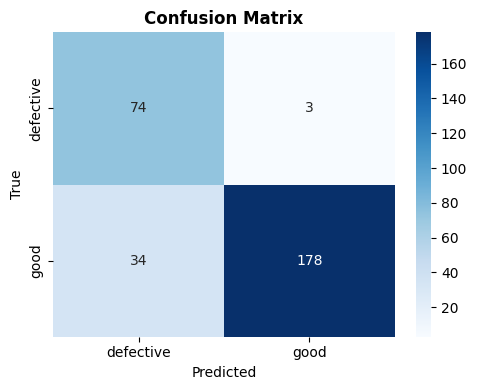

In [19]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in loader['val']:
        inputs  = inputs.to(DEVICE)
        probs   = torch.softmax(model(inputs), dim=1)
        preds   = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, DEFECT_IDX].cpu().numpy())

print('Classification Report')
print('=' * 45)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

binary_labels = [1 if l == DEFECT_IDX else 0 for l in all_labels]
auc = roc_auc_score(binary_labels, all_probs)
print(f'AUC-ROC: {auc:.4f}')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

In [ ]:
meta = {
    'patch_w':     PATCH_W,
    'patch_h':     PATCH_H,
    'img_size':    IMG_SIZE,
    'class_names': CLASS_NAMES,
    'defect_idx':  DEFECT_IDX,
    'best_val_f1': round(best_f1, 4),
}
with open(f'{WORK_DIR}/pcb_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Files saved to /kaggle/working:')
print(f'  pcb_best_model.pth   ({Path(MODEL_PATH).stat().st_size/1e6:.1f} MB)')
print(f'  pcb_model_meta.json')
print(f'\nBest val F1 (defective class): {best_f1:.4f}')
print('\nDownload both files from the Output panel to use outside Kaggle.')

Files saved to /kaggle/working:
  pcb_best_model.pth   (17.6 MB)
  pcb_model_meta.json

Best val F1 (defective class): 0.5725

Download both files from the Output panel to use outside Kaggle.
